In [1]:
!pip install ruptures
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
import ruptures as rpt
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/processed/delhi_2019_all_stations.csv')
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

# Use Patparganj — best data quality
station = 'Patparganj'
df_st = df[df['Station']==station].copy()
df_st = df_st.set_index('Timestamp').resample('1H').mean(numeric_only=True)
df_st = df_st.ffill().bfill()
df_st['Season'] = df_st.index.month.map({
    12:'Winter',1:'Winter',2:'Winter',
    3:'Summer',4:'Summer',5:'Summer',
    6:'Monsoon',7:'Monsoon',8:'Monsoon',9:'Monsoon',
    10:'Post-Monsoon',11:'Post-Monsoon'
})

print("Shape:", df_st.shape)
print("Date range:", df_st.index.min(), "→", df_st.index.max())
df_st[['PM25','NO2','CO','Benzene']].describe().round(2)

Shape: (8760, 26)
Date range: 2019-01-01 00:00:00 → 2019-12-31 23:00:00


,PM25,NO2,CO,Benzene
count,8760.00,8760.00,8760.00,8760.00
mean,100.36,20.16,1.08,2.16
std,98.88,13.62,0.97,2.52
min,1.00,0.40,0.00,0.00
25%,36.25,9.93,0.52,0.52
50%,66.00,17.45,0.75,1.27
75%,127.75,27.42,1.23,2.72
max,983.00,272.60,9.70,15.00


In [2]:
# 3-sigma and IQR flagging
pollutants_anomaly = ['PM25', 'PM10', 'NO2', 'CO', 'Benzene']

stats_flags = pd.DataFrame(index=df_st.index)
for col in pollutants_anomaly:
    mean_v = df_st[col].mean()
    std_v = df_st[col].std()
    Q1 = df_st[col].quantile(0.25)
    Q3 = df_st[col].quantile(0.75)
    IQR = Q3 - Q1
    stats_flags[f'{col}_3sigma'] = df_st[col] > (mean_v + 3*std_v)
    stats_flags[f'{col}_IQR'] = df_st[col] > (Q3 + 1.5*IQR)

stats_flags['any_anomaly'] = stats_flags.any(axis=1)
stats_flags['anomaly_count'] = stats_flags.sum(axis=1)

print("=== STATISTICAL ANOMALY SUMMARY ===\n")
print(f"Total hours: {len(df_st)}")
print(f"Anomalous hours (any variable): {stats_flags['any_anomaly'].sum()}")
print(f"% anomalous: {stats_flags['any_anomaly'].mean()*100:.1f}%")
print(f"\nPer-variable anomaly counts:")
for col in pollutants_anomaly:
    n = stats_flags[f'{col}_3sigma'].sum()
    print(f"  {col}: {n} hours ({n/len(df_st)*100:.1f}%)")

=== STATISTICAL ANOMALY SUMMARY ===

Total hours: 8760
Anomalous hours (any variable): 1750
% anomalous: 20.0%

Per-variable anomaly counts:
  PM25: 186 hours (2.1%)
  PM10: 145 hours (1.7%)
  NO2: 102 hours (1.2%)
  CO: 198 hours (2.3%)
  Benzene: 239 hours (2.7%)


In [3]:
# Multivariate anomaly detection
iso_features = ['PM25','PM10','NO2','NO','CO','Benzene']
df_iso = df_st[iso_features].dropna()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_iso)

# Train Isolation Forest
iso = IsolationForest(
    contamination=0.05,  # flag 5% as anomalous
    random_state=42,
    n_estimators=200
)
iso_labels = iso.fit_predict(X_scaled)
iso_scores = iso.score_samples(X_scaled)  # anomaly score

df_iso['iso_label'] = iso_labels      # -1 = anomaly, 1 = normal
df_iso['iso_score'] = iso_scores      # lower = more anomalous

n_anomalies = (iso_labels == -1).sum()
print(f"Isolation Forest detected: {n_anomalies} anomalous hours")
print(f"Percentage: {n_anomalies/len(df_iso)*100:.1f}%")

# Monthly distribution of anomalies
df_iso['Month'] = df_iso.index.month
monthly = df_iso.groupby('Month')['iso_label'].apply(
    lambda x: (x==-1).sum()
).reset_index()
monthly.columns = ['Month','Anomaly_Count']
month_names = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',
               7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}
monthly['Month_Name'] = monthly['Month'].map(month_names)
print("\nAnomalies by month:")
print(monthly[['Month_Name','Anomaly_Count']].to_string(index=False))

Isolation Forest detected: 438 anomalous hours
Percentage: 5.0%

Anomalies by month:
Month_Name  Anomaly_Count
       Jan             84
       Feb             12
       Mar              0
       Apr             31
       May             64
       Jun             29
       Jul              6
       Aug             16
       Sep              0
       Oct             39
       Nov             90
       Dec             67


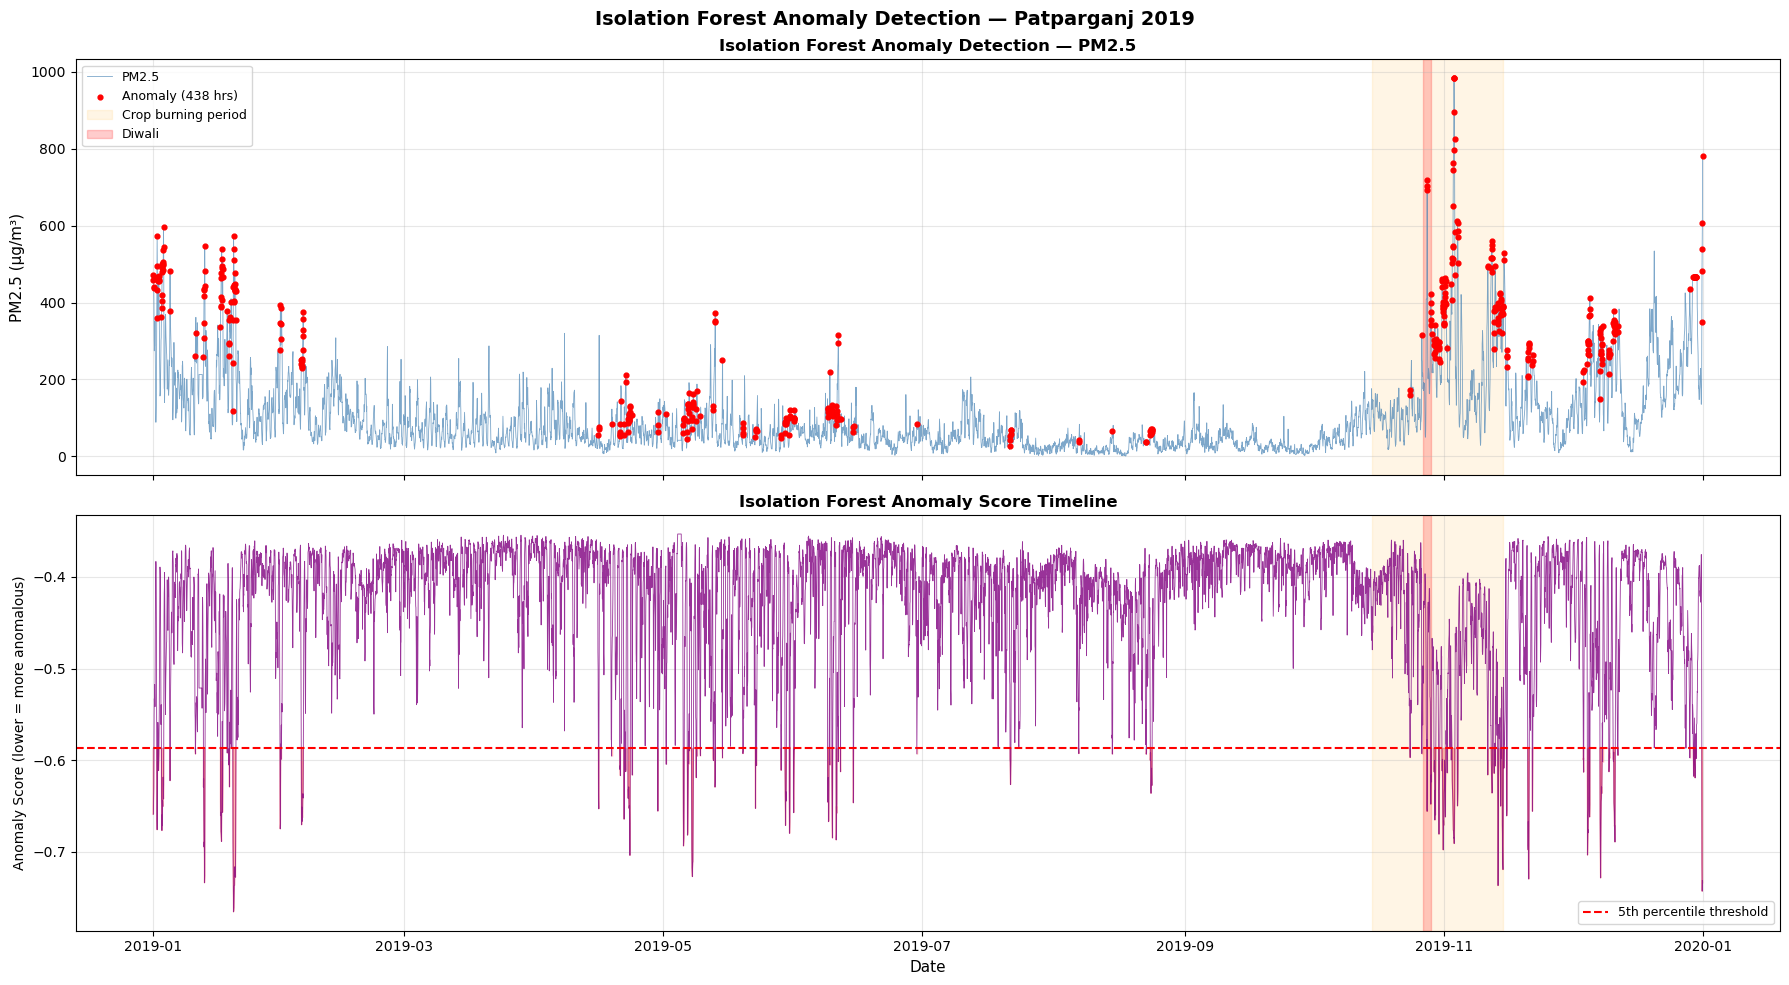

Saved!


In [4]:
fig, axes = plt.subplots(2, 1, figsize=(18, 10), sharex=True)

# Top — PM2.5 with anomalies highlighted
normal = df_iso[df_iso['iso_label']==1]
anomaly = df_iso[df_iso['iso_label']==-1]

axes[0].plot(df_iso.index, df_iso['PM25'], 
             color='steelblue', linewidth=0.6, alpha=0.7, label='PM2.5')
axes[0].scatter(anomaly.index, anomaly['PM25'],
                color='red', s=12, zorder=5, 
                label=f'Anomaly ({len(anomaly)} hrs)')
axes[0].axvspan(pd.Timestamp('2019-10-15'), pd.Timestamp('2019-11-15'),
                alpha=0.1, color='orange', label='Crop burning period')
axes[0].axvspan(pd.Timestamp('2019-10-27'), pd.Timestamp('2019-10-29'),
                alpha=0.2, color='red', label='Diwali')
axes[0].set_ylabel('PM2.5 (µg/m³)', fontsize=11)
axes[0].set_title('Isolation Forest Anomaly Detection — PM2.5', 
                  fontweight='bold', fontsize=12)
axes[0].legend(fontsize=9, loc='upper left')
axes[0].grid(True, alpha=0.3)

# Bottom — anomaly score over time
axes[1].plot(df_iso.index, df_iso['iso_score'],
             color='purple', linewidth=0.6, alpha=0.8)
axes[1].axhline(df_iso['iso_score'].quantile(0.05), 
                color='red', linestyle='--', linewidth=1.5,
                label='5th percentile threshold')
axes[1].fill_between(df_iso.index, df_iso['iso_score'],
                     df_iso['iso_score'].quantile(0.05),
                     where=df_iso['iso_score'] < df_iso['iso_score'].quantile(0.05),
                     color='red', alpha=0.3)
axes[1].axvspan(pd.Timestamp('2019-10-15'), pd.Timestamp('2019-11-15'),
                alpha=0.1, color='orange')
axes[1].axvspan(pd.Timestamp('2019-10-27'), pd.Timestamp('2019-10-29'),
                alpha=0.2, color='red')
axes[1].set_ylabel('Anomaly Score (lower = more anomalous)', fontsize=10)
axes[1].set_title('Isolation Forest Anomaly Score Timeline', 
                  fontweight='bold', fontsize=12)
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)
axes[1].set_xlabel('Date', fontsize=11)

plt.suptitle(f'Isolation Forest Anomaly Detection — {station} 2019',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/24_isolation_forest.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved!")

In [5]:
import pandas as pd
import numpy as np
import ruptures as rpt
import os

df_st.index = pd.to_datetime(df_st.index)
df_st = df_st.sort_index()
df_st = df_st.resample('3H').mean(numeric_only=True)
pm25_series = df_st['PM25'].ffill().values

pm25_series = df_st['PM25'].ffill().values

model = rpt.Pelt(model='l2', min_size=16, jump=5)
model.fit(pm25_series)
breakpoints = model.predict(pen=80)

print(f"Detected {len(breakpoints)-1} change points")
print("\nChange point dates:")

changepoint_dates = []

for bp in breakpoints[:-1]:
    if bp < len(df_st):
        date = df_st.index[bp]
        window = 16
        pm25_before = pm25_series[max(0, bp - window):bp].mean()
        pm25_after = pm25_series[bp:min(len(pm25_series), bp + window)].mean()
        changepoint_dates.append({
            'Date': date.strftime('%Y-%m-%d %H:%M'),
            'PM25_Before': round(pm25_before, 1),
            'PM25_After': round(pm25_after, 1),
            'Change': round(pm25_after - pm25_before, 1)
        })
        print(f"{date.strftime('%Y-%m-%d %H:%M')} | "
              f"Before: {pm25_before:.0f} → After: {pm25_after:.0f} | "
              f"Change: {pm25_after - pm25_before:+.0f} µg/m³")

cp_df = pd.DataFrame(changepoint_dates)

os.makedirs('../figures', exist_ok=True)
cp_df.to_csv('../figures/25_changepoints.csv', index=False)

print("\nSaved to ../figures/25_changepoints.csv")

Detected 121 change points

Change point dates:
2019-01-03 12:00 | Before: 353 → After: 258 | Change: -95 µg/m³
2019-01-06 00:00 | Before: 237 → After: 173 | Change: -65 µg/m³
2019-01-08 12:00 | Before: 173 → After: 142 | Change: -31 µg/m³
2019-01-11 00:00 | Before: 149 → After: 232 | Change: +84 µg/m³
2019-01-13 12:00 | Before: 244 → After: 119 | Change: -125 µg/m³
2019-01-16 00:00 | Before: 106 → After: 305 | Change: +199 µg/m³
2019-01-18 12:00 | Before: 302 → After: 306 | Change: +4 µg/m³
2019-01-21 15:00 | Before: 268 → After: 70 | Change: -198 µg/m³
2019-01-24 18:00 | Before: 123 → After: 75 | Change: -47 µg/m³
2019-01-27 06:00 | Before: 89 → After: 107 | Change: +18 µg/m³
2019-01-29 18:00 | Before: 109 → After: 203 | Change: +95 µg/m³
2019-02-01 06:00 | Before: 194 → After: 180 | Change: -14 µg/m³
2019-02-04 09:00 | Before: 157 → After: 200 | Change: +42 µg/m³
2019-02-06 21:00 | Before: 196 → After: 63 | Change: -132 µg/m³
2019-02-09 09:00 | Before: 60 → After: 122 | Change: +61 

Macro change points detected: 66


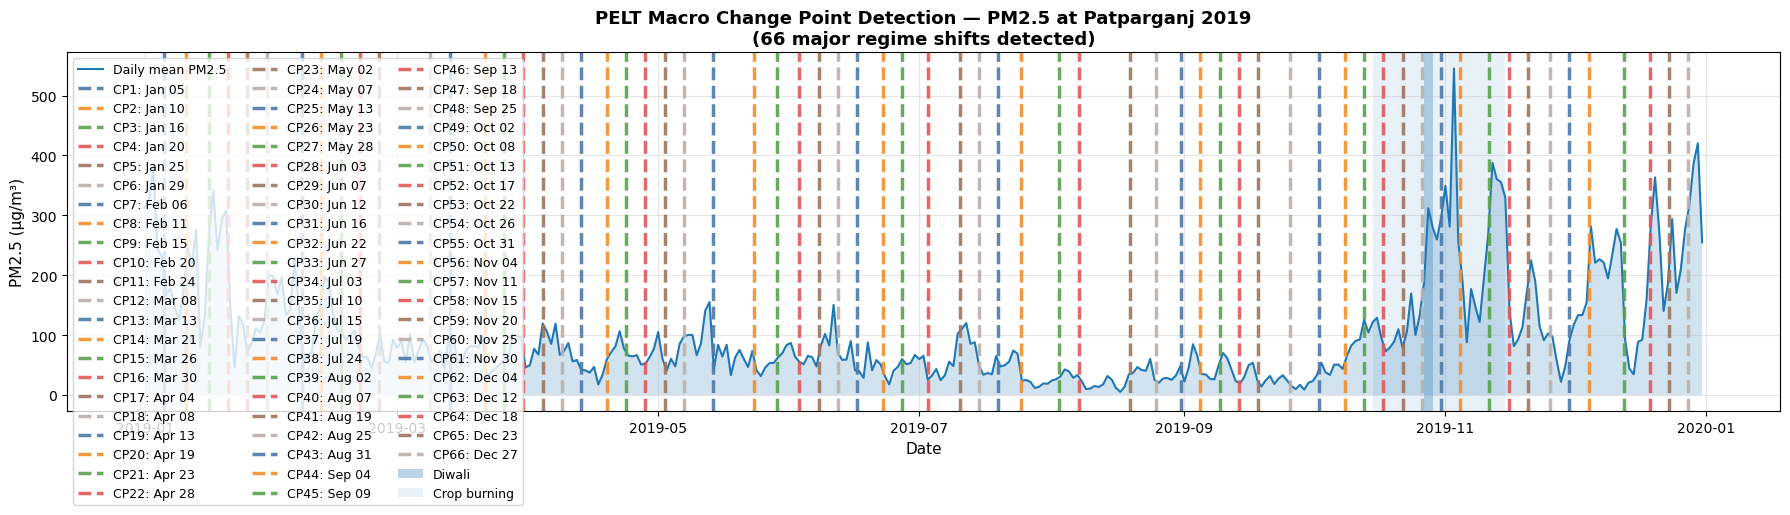


Change point dates:
  2019-01-05 | Before 7d avg: 312 → After: 176 | Change: -136 µg/m³
  2019-01-10 | Before 7d avg: 184 → After: 221 | Change: +37 µg/m³
  2019-01-16 | Before 7d avg: 178 → After: 235 | Change: +57 µg/m³
  2019-01-20 | Before 7d avg: 239 → After: 108 | Change: -130 µg/m³
  2019-01-25 | Before 7d avg: 183 → After: 128 | Change: -55 µg/m³
  2019-01-29 | Before 7d avg: 102 → After: 177 | Change: +75 µg/m³
  2019-02-06 | Before 7d avg: 178 → After: 119 | Change: -59 µg/m³
  2019-02-11 | Before 7d avg: 121 → After: 138 | Change: +17 µg/m³
  2019-02-15 | Before 7d avg: 137 → After: 90 | Change: -47 µg/m³
  2019-02-20 | Before 7d avg: 117 → After: 64 | Change: -54 µg/m³
  2019-02-24 | Before 7d avg: 77 → After: 75 | Change: -2 µg/m³
  2019-03-08 | Before 7d avg: 78 → After: 72 | Change: -7 µg/m³
  2019-03-13 | Before 7d avg: 68 → After: 79 | Change: +11 µg/m³
  2019-03-21 | Before 7d avg: 76 → After: 53 | Change: -23 µg/m³
  2019-03-26 | Before 7d avg: 60 → After: 74 | Chan

In [6]:
import matplotlib.pyplot as plt
import ruptures as rpt
import pandas as pd
import numpy as np
import os

model_macro = rpt.Pelt(model='l2', min_size=32, jump=6)
model_macro.fit(pm25_series)
breakpoints_macro = model_macro.predict(pen=500)

print(f"Macro change points detected: {len(breakpoints_macro)-1}")

fig, ax = plt.subplots(figsize=(18, 5))

daily_pm25 = df_st['PM25'].resample('D').mean()
ax.plot(daily_pm25.index, daily_pm25.values,
        linewidth=1.5, label='Daily mean PM2.5')
ax.fill_between(daily_pm25.index, daily_pm25.values,
                alpha=0.2)

season_colors_cp = ['#4e79a7','#f28e2b','#59a14f',
                    '#e15759','#9c755f','#bab0ac']

for i, bp in enumerate(breakpoints_macro[:-1]):
    if bp < len(df_st):
        date = df_st.index[bp]
        color = season_colors_cp[i % len(season_colors_cp)]
        ax.axvline(date, linestyle='--',
                   linewidth=2.5, alpha=0.9,
                   color=color,
                   label=f'CP{i+1}: {date.strftime("%b %d")}')

ax.axvspan(pd.Timestamp('2019-10-27'), pd.Timestamp('2019-10-29'),
           alpha=0.3, label='Diwali')
ax.axvspan(pd.Timestamp('2019-10-15'), pd.Timestamp('2019-11-15'),
           alpha=0.1, label='Crop burning')

ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('PM2.5 (µg/m³)', fontsize=11)
ax.set_title(f'PELT Macro Change Point Detection — PM2.5 at {station} 2019\n'
             f'({len(breakpoints_macro)-1} major regime shifts detected)',
             fontsize=13, fontweight='bold')

ax.legend(fontsize=9, ncol=3)
ax.grid(True, alpha=0.3)

plt.tight_layout()

os.makedirs('../figures', exist_ok=True)
plt.savefig('../figures/25b_changepoint_macro.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nChange point dates:")

window = 56

for bp in breakpoints_macro[:-1]:
    if bp < len(df_st):
        date = df_st.index[bp]
        before = pm25_series[max(0, bp-window):bp].mean()
        after = pm25_series[bp:min(len(pm25_series), bp+window)].mean()
        print(f"  {date.strftime('%Y-%m-%d')} | "
              f"Before 7d avg: {before:.0f} → After: {after:.0f} | "
              f"Change: {after-before:+.0f} µg/m³")

Major regime shifts detected: 0


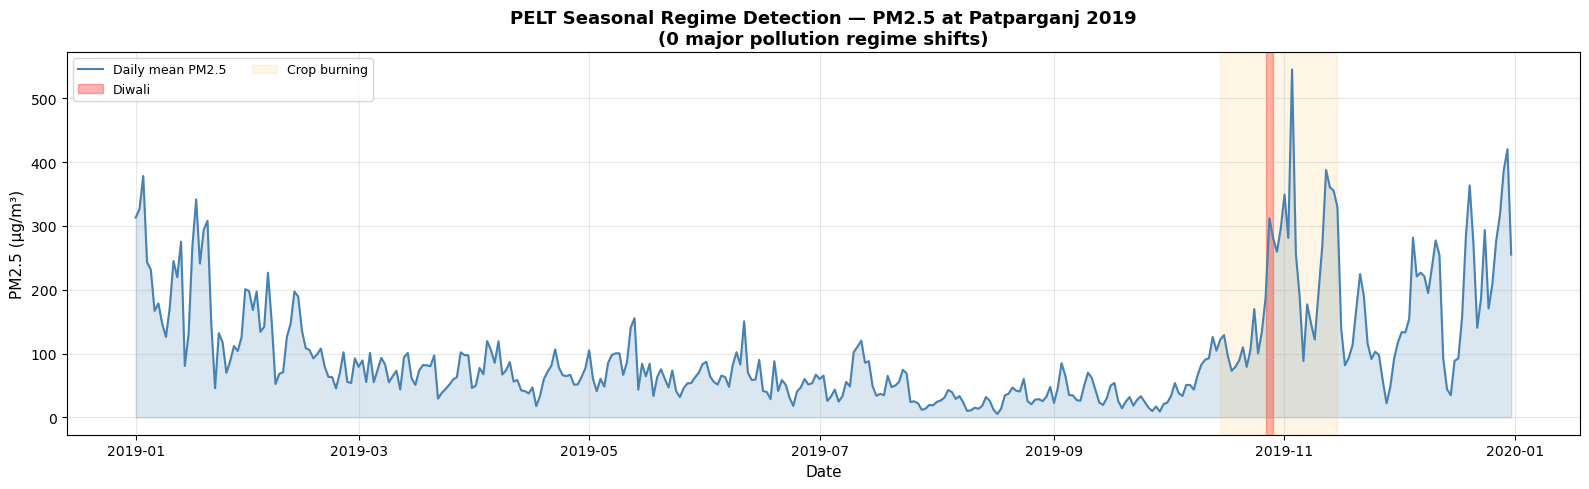


Major regime shift dates:


In [7]:
# Final PELT with very high penalty — only major seasonal transitions
model_final = rpt.Pelt(model='rbf', min_size=168, jump=24)
model_final.fit(pm25_series)
breakpoints_final = model_final.predict(pen=3000)

print(f"Major regime shifts detected: {len(breakpoints_final)-1}")

fig, ax = plt.subplots(figsize=(16, 5))
daily_pm25 = df_st['PM25'].resample('D').mean()
ax.plot(daily_pm25.index, daily_pm25.values,
        color='steelblue', linewidth=1.5, label='Daily mean PM2.5')
ax.fill_between(daily_pm25.index, daily_pm25.values, alpha=0.2, color='steelblue')

colors_final = ['#e15759','#f28e2b','#59a14f','#4e79a7','#9c755f','#76b7b2']
for i, bp in enumerate(breakpoints_final[:-1]):
    if bp < len(df_st):
        date = df_st.index[bp]
        before = pm25_series[max(0,bp-168):bp].mean()
        after = pm25_series[bp:min(len(pm25_series),bp+168)].mean()
        ax.axvline(date, color=colors_final[i % len(colors_final)],
                   linestyle='--', linewidth=2.5, alpha=0.9,
                   label=f'CP{i+1}: {date.strftime("%b %d")} ({after-before:+.0f} µg/m³)')

ax.axvspan(pd.Timestamp('2019-10-27'), pd.Timestamp('2019-10-29'),
           alpha=0.3, color='red', label='Diwali')
ax.axvspan(pd.Timestamp('2019-10-15'), pd.Timestamp('2019-11-15'),
           alpha=0.1, color='orange', label='Crop burning')

ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('PM2.5 (µg/m³)', fontsize=11)
ax.set_title(f'PELT Seasonal Regime Detection — PM2.5 at {station} 2019\n'
             f'({len(breakpoints_final)-1} major pollution regime shifts)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=9, ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../figures/25c_changepoint_seasonal.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nMajor regime shift dates:")
for i, bp in enumerate(breakpoints_final[:-1]):
    if bp < len(df_st):
        date = df_st.index[bp]
        before = pm25_series[max(0,bp-168):bp].mean()
        after = pm25_series[bp:min(len(pm25_series),bp+168)].mean()
        print(f"  CP{i+1}: {date.strftime('%Y-%m-%d')} | "
              f"{before:.0f} → {after:.0f} µg/m³ | Change: {after-before:+.0f}")

=== TOP POLLUTION EPISODES DETECTED ===

Episode            Start              End  Duration_hrs  Peak_PM25  Mean_PM25  Peak_NO2 Month_Name
     E1 2019-01-01 00:00 2019-01-01 03:00             4      472.2      452.1      29.8        Jan
     E2 2019-01-01 20:00 2019-01-02 00:00             5      571.8      465.2      36.5        Jan
     E3 2019-01-02 05:00 2019-01-02 08:00             4      468.8      460.0      28.2        Jan
     E4 2019-01-02 22:00 2019-01-03 11:00            14      595.5      478.9      42.5        Jan
     E5 2019-01-12 20:00 2019-01-13 04:00             9      547.0      407.0      59.6        Jan
     E6 2019-01-16 20:00 2019-01-17 09:00            13      538.0      451.6      54.2        Jan
     E7 2019-01-18 20:00 2019-01-19 00:00             5      363.5      313.8      49.7        Jan
     E8 2019-01-19 18:00 2019-01-20 11:00            18      573.0      414.9      97.5        Jan
     E9 2019-01-30 21:00 2019-01-31 05:00             6      394.8  

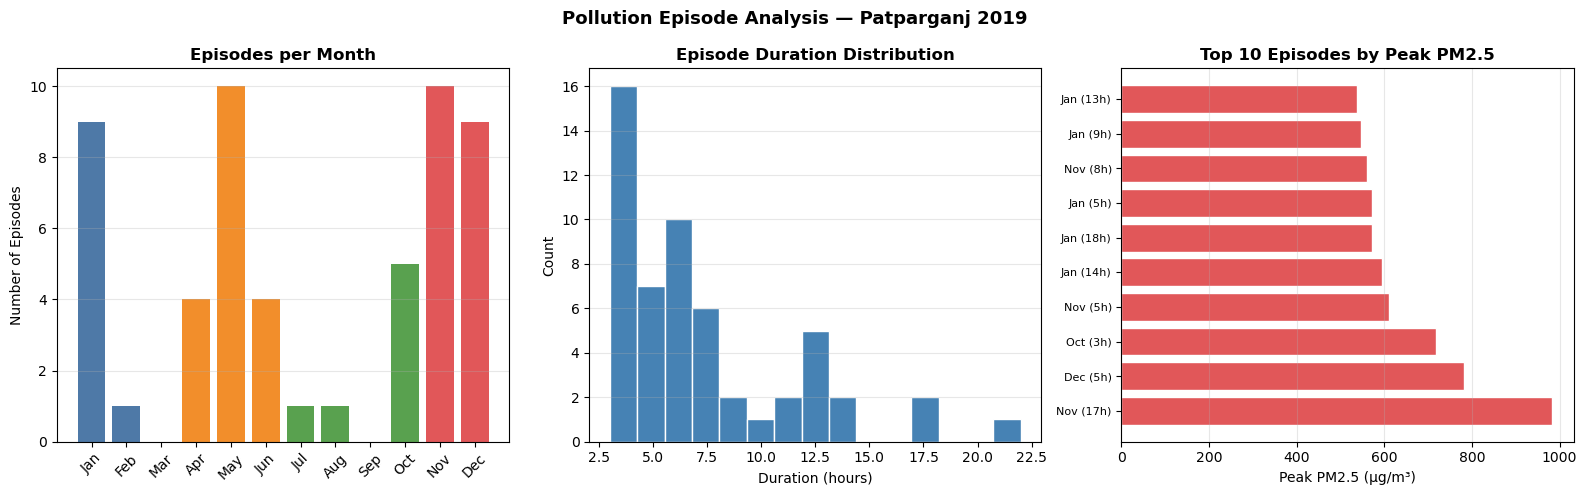


Total episodes detected: 54
Longest episode: 22 hours
Highest peak PM2.5: 983.0 µg/m³


In [8]:
# Characterize the top pollution episodes found by Isolation Forest
anomaly_periods = df_iso[df_iso['iso_label']==-1].copy()

# Find contiguous anomaly clusters
anomaly_periods['gap'] = (
    anomaly_periods.index.to_series().diff() > pd.Timedelta('3H')
).cumsum()

episodes = []
for gap_id, group in anomaly_periods.groupby('gap'):
    if len(group) >= 3:  # at least 3 hours
        episodes.append({
    'Episode': f'E{len(episodes)+1}',
    'Start': group.index.min().strftime('%Y-%m-%d %H:%M'),
    'End': group.index.max().strftime('%Y-%m-%d %H:%M'),
    'Duration_hrs': len(group),
    'Peak_PM25': round(group['PM25'].max(), 1),
    'Mean_PM25': round(group['PM25'].mean(), 1),
    'Peak_NO2': round(group['NO2'].max(), 1),
    'Peak_CO': round(group['CO'].max(), 3),
    'Month': group.index.min().month
})

ep_df = pd.DataFrame(episodes)
ep_df['Month_Name'] = ep_df['Month'].map(month_names)
print("=== TOP POLLUTION EPISODES DETECTED ===\n")
print(ep_df[['Episode','Start','End','Duration_hrs',
             'Peak_PM25','Mean_PM25','Peak_NO2','Month_Name']].to_string(index=False))
ep_df.to_csv('../figures/26_episodes.csv', index=False)

# Visualize episode summary
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Episodes per month
ep_monthly = ep_df.groupby('Month_Name').size().reindex(
    ['Jan','Feb','Mar','Apr','May','Jun',
     'Jul','Aug','Sep','Oct','Nov','Dec'], fill_value=0)
colors_m = ['#4e79a7']*3+['#f28e2b']*3+['#59a14f']*4+['#e15759']*2
axes[0].bar(ep_monthly.index, ep_monthly.values, color=colors_m)
axes[0].set_title('Episodes per Month', fontweight='bold')
axes[0].set_ylabel('Number of Episodes')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True, alpha=0.3, axis='y')

# Episode duration distribution
axes[1].hist(ep_df['Duration_hrs'], bins=15, 
             color='steelblue', edgecolor='white')
axes[1].set_title('Episode Duration Distribution', fontweight='bold')
axes[1].set_xlabel('Duration (hours)')
axes[1].set_ylabel('Count')
axes[1].grid(True, alpha=0.3, axis='y')

# Peak PM2.5 per episode
top_ep = ep_df.nlargest(10, 'Peak_PM25')
axes[2].barh(range(len(top_ep)), top_ep['Peak_PM25'],
             color='#e15759', edgecolor='white')
axes[2].set_yticks(range(len(top_ep)))
axes[2].set_yticklabels(
    [f"{r['Month_Name']} ({r['Duration_hrs']}h)" 
     for _, r in top_ep.iterrows()], fontsize=8)
axes[2].set_title('Top 10 Episodes by Peak PM2.5', fontweight='bold')
axes[2].set_xlabel('Peak PM2.5 (µg/m³)')
axes[2].grid(True, alpha=0.3, axis='x')

plt.suptitle('Pollution Episode Analysis — Patparganj 2019',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/26_episode_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\nTotal episodes detected: {len(ep_df)}")
print(f"Longest episode: {ep_df['Duration_hrs'].max()} hours")
print(f"Highest peak PM2.5: {ep_df['Peak_PM25'].max()} µg/m³")